# Final Project DS4420 - Eric Gerber 
Alina Gonzalez, Veronica Song, Sophia Yang 

We want to tackle 2 issues 
1. Human loneliness/need for compansionship or support through a pet or animal 
2. Helping shelter animals get adopted by the right family (reduces shelter population)

### Our models 
- MLP model that takes in your personality traits or needs and matches you to a pet type 
- CNN that identifies type of animal + traits about them (?) 
- Bayesian model that predicts likelihood of an animal being adopted based on identified traits from the CNN 

## MLP that matches you to pet type!

This MLP is manually created using code we went over together in class :)) 

In [1]:
import numpy as np 
import pandas as pd 

from sklearn.neural_network import MLPClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score

from tqdm import tqdm

In [79]:
# data cleanup 
pet_qs = pd.read_csv("pet_questionaire.csv")
pet_qs.head() 


,sort,ind_ID,trait_pet3,grand_pare13,grand_pare23,parent3,sex,city_YN,age,salary,region,reason1,reason2,reason3,reason4,reason5,replace1,replace2,replace3
0,1,a1,2,2.0,2.0,2.0,Female,Urban_area,21.0,5000.0,chongqing,Yes,No,Yes,Yes,Yes,NaN,Yes,NaN
1,2,a2,1,1.0,1.0,1.0,Female,Urban_area,22.0,8000.0,hunan,No,No,Yes,Yes,No,NaN,Yes,NaN
2,3,a3,2,NaN,2.0,0.0,Female,Urban_area,22.0,5000.0,fujian,Yes,No,Yes,No,No,Yes,Yes,NaN
3,4,a4,0,0.0,0.0,0.0,Female,Urban_area,19.0,1500.0,guangdong,NaN,NaN,NaN,NaN,NaN,No,No,NaN
4,5,a5,2,0.0,0.0,2.0,Male,Urban_area,33.0,7000.0,shandong,No,No,Yes,No,No,No,No,NaN


In [143]:
# i did NOT feel like writing out reason 1 through 5 lol 
pet_qs = pd.read_csv("pet_questionaire.csv")
questions = ["reason" + str(i) for i in range(1, 6)] + ["replace" + str(i) for i in range(1, 4)]

for col in questions: 
    pet_qs[col] = pet_qs[col].map({"Yes": 1, "No": 0})

# other columns that I care about 
pet_qs = pd.get_dummies(pet_qs, columns=["sex", "city_YN"], dtype=int)

features = questions + ["sex_Female", "sex_Male", "trait_pet3", "age", "salary", "city_YN_Rural_area", "city_YN_Urban_area"]
cleaned = pet_qs[features]
cleaned = cleaned.fillna(0)

# now we prep the data for training and stuff 
y = cleaned["trait_pet3"] # does the person have a pet, and what kind of pet!!! 

X = cleaned.drop('trait_pet3', axis=1) # DROPPPP ITTT

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=24,  
)

# scale
scaler = MinMaxScaler()
# guys i don't remmber if u scale the x train and test sep or tg but we do sep horray 
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [144]:
# convert to numpy arrays so we can math with it :3
X_train = X_train_scaled 
X_test = X_test_scaled 
y_train = y_train.to_numpy()
y_test = y_test.to_numpy()

In [ ]:
# pets vs has no pets!!!
y_train = [1 if _ in [1, 2] else 0 for _ in y_train]
y_test = [1 if _ in [1, 2] else 0 for _ in y_test]

In [ ]:
# hyperparameters
eta = 0.0005 # chose a really small one! 
q = 32 # 32 hidden units :3

d = X_train_scaled.shape[1]

# added bias term to see if it helps (it did horray!) then also tried to make them smaller to prevent explosion
W1 = np.random.randn(d, q) * 0.01
b1 = np.random.randn(q, 1) * 0.001
W2 = np.random.randn(q, 1) # left this guy blank cus I was just messing around ;w;
b2 = np.random.randn(1, 1)  * 0.001

# SIGMOID FUNCTION 
def sigmoid(x): 
    return 1 / (1 + np.exp(-x))

errors = []
epochs = 1000 # got this by messing around 
n = X_train_scaled.shape[0]
d = X_train_scaled.shape[1]


for epoch in tqdm(range(epochs)):
    dW2 = 0
    db2 = 0
    for i, j in enumerate(y_train):
        x = np.reshape(X_train_scaled[i], (d,1))
        h = np.maximum(0, W1.T.dot(x) + b1)
        y_hat = sigmoid(W2.T.dot(h) + b2)

    W2 = W2 - eta * dW2
    b2 = b2 - eta * db2
    
    dW1 = 0
    db1 = 0
    for i, j in enumerate(y_train):
        x = np.reshape(X_train_scaled[i], (d,1))
        h = np.maximum(0, W1.T.dot(x) + b1)
        y_hat = sigmoid(W2.T.dot(h) + b2)
        mat1 = np.heaviside(W1.T.dot(x) + b1, 0)

        dW1 += (1/n) * (y_hat - y_train[i]) * np.kron(x, (W2 * mat1).T)
        db1 += (1/n) * (y_hat - y_train[i]) * (W2 * mat1)

    W1 = W1 - eta * dW1
    b1 = b1 - eta * db1
    
    preds_train = []
    for i in range(n):
        x = X_train_scaled[i].reshape(d,1)
        h = np.maximum(0, W1.T.dot(x) + b1)
        preds_train.append(sigmoid(W2.T.dot(h) + b2)[0,0])
    
    e = np.mean((np.array(preds_train) - y_train)**2)
    errors.append(e)
# now we predict 
y_test_pred_prob = []
y_test_pred = []

for i in range(X_test_scaled.shape[0]):
    x = X_test_scaled[i].reshape(d,1)          
    h = np.maximum(0, W1.T.dot(x) + b1)
    y_hat = sigmoid(W2.T.dot(h) + b2)
    y_test_pred_prob.append(y_hat[0,0]) 
    y_test_pred.append(int(y_hat[0][0] >= 0.8))

y_test_pred_prob = np.array(y_test_pred_prob)
y_test_pred = np.array(y_test_pred)

from sklearn.metrics import accuracy_score, r2_score

test_r2 = r2_score(y_test, y_test_pred)
accuracy = accuracy_score(y_test, y_test_pred)
print(f"Test set r2: {test_r2:.2f}")
print(f"Test set accuracy: {accuracy*100:.2f}%")


100%|██████████| 1000/1000 [01:07<00:00, 14.92it/s]

Test set r2: -1.34
Test set accuracy: 67.00%


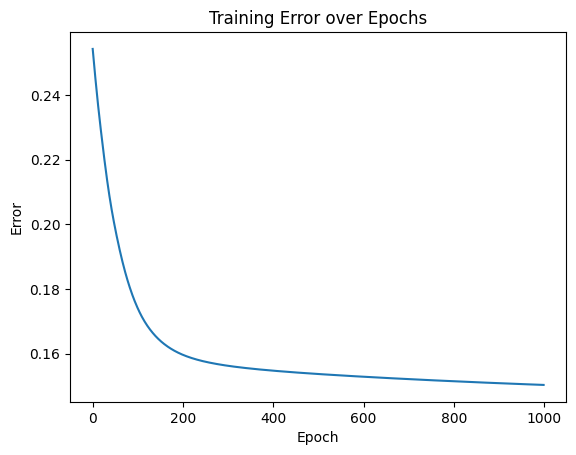

In [151]:
plt.plot(errors)
plt.xlabel("Epoch")
plt.ylabel("Error")
plt.title("Training Error over Epochs")
plt.show()

In [147]:
model = {
    "W1": W1,
    "b1": b1,
    "W2": W2,
    "b2": b2,
    "input_dim": d,
    "hidden_units": q
}
import pickle

with open("mlp_model.pkl", "wb") as f:
    pickle.dump(model, f)

print("Model saved to nn_model.pkl")

Model saved to nn_model.pkl


In [148]:
import numpy as np
import pickle
with open("mlp_model.pkl", "rb") as f:
    model = pickle.load(f)

W1 = model["W1"]
b1 = model["b1"]
W2 = model["W2"]
b2 = model["b2"]


y_test_pred_prob = []
y_test_pred = []

for i in range(X_test_scaled.shape[0]):
    x = X_test_scaled[i].reshape(d, 1)
    h = np.maximum(0, W1.T.dot(x) + b1)
    y_hat = sigmoid(W2.T.dot(h) + b2)
    y_test_pred_prob.append(y_hat[0, 0])
    y_test_pred.append(int(y_hat[0][0] >= 0.8))

y_test_pred_prob = np.array(y_test_pred_prob)
y_test_pred = np.array(y_test_pred)

from sklearn.metrics import accuracy_score, r2_score, classification_report

test_r2 = r2_score(y_test, y_test_pred)
accuracy = accuracy_score(y_test, y_test_pred)
print(f"Test set r2: {test_r2:.2f}")
print(f"Test set accuracy: {accuracy*100:.2f}%")
print(classification_report(y_test, y_test_pred))

Test set r2: -1.34
Test set accuracy: 67.00%
              precision    recall  f1-score   support

           0       0.33      0.94      0.49        17
           1       0.98      0.61      0.76        83

    accuracy                           0.67       100
   macro avg       0.66      0.78      0.62       100
weighted avg       0.87      0.67      0.71       100



Not terrible!!!

In [ ]:
# mlp stuff (NOT BY HAND!) this is just experimentation
mlp = MLPClassifier(
    hidden_layer_sizes=(256, 128, 128, 32),  
    activation='relu',
    max_iter=2000,
    random_state=42
)

mlp.fit(X_train_scaled, y_train)
print(f"Number of iterations: {mlp.n_iter_}")
print(f"Final loss: {mlp.loss_:.4f}")


# going to predic t now
y_pred = mlp.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

Number of iterations: 222
Final loss: 0.4198
Test Accuracy: 0.5400 (54.00%)
